#                 DU POINT DE L'ANNONCE AU NOEUD DU RESEAU
    ## CREATION ET MODIFICATION DU RESEAU EXISTANT PAR LA CREATION DE NOUVEAUX NOEUDS AU DEPART DU POINT DE L'ANNONCE
    ## ANALYSE DU CHEMIN LE PLUS COURT ENTRE TOUS LES NOEUDS D'UN RESEAU


In [1]:
##CREATE SHAPEFILL DATA FROM EXCEL FILE
import geopandas as gpd
import fiona
import pandas as pd
from collections import OrderedDict
from pyproj import Transformer
from geopandas import GeoDataFrame
from shapely.geometry import Point
import folium
import geopy
import networkx
import osmnx as ox
#import Rtree
import shapely
import matplotlib.pyplot as plt
import shapefile
from itoolbox import connect_poi
import momepy
import pickle
#http://docs.momepy.org/en/stable/user_guide/graph/convert.html

c:\users\ablanchi\appdata\local\programs\python\python36\lib\site-packages\geopandas\_compat.py:110: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


# CREATE NETWORK FROM POINTS AND NETWORK
    INPUT : SHAPEFILE OF NETWORK AND SHAPEFILE OF POINTS
    OUPUT : ne, nn_only, new_edges_bez_poi_link, nodes_without_ads, nodes_without_ads_with_information
    OUR NEW NETWORK IS COMPOSED TO TWO DATAFRAME : 1/ EDGES == "new_edges_bez_linkpoi" 2/ NODES == "nodes_without_ADS"')

In [4]:
VILLE = "ALPES-MARITIMES"

In [2]:
streets = gpd.read_file("C:\\GIT\\2022\\TOPONOMASCAPE\\STREETS\\ROUTES_06_SELECTED_WITH_CITY.shp")

In [3]:
streets.NOM_max = streets.NOM_max.str.upper()
streets = streets[streets.NOM_max == VILLE]

NameError: name 'VILLE' is not defined

In [5]:
len(streets)

120774

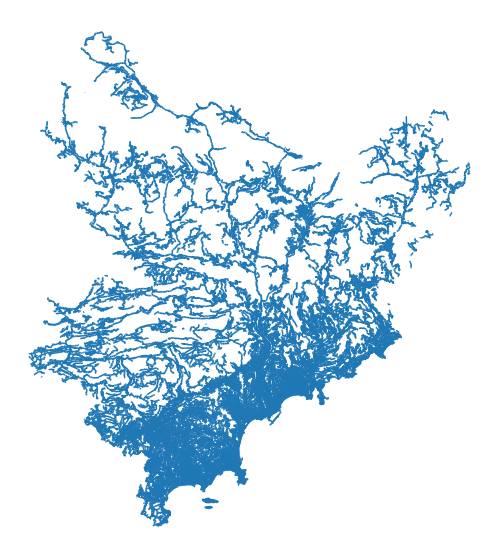

In [6]:
f, ax = plt.subplots(figsize=(10, 10))
streets.plot(ax=ax)
ax.set_axis_off()
plt.show()

In [9]:
#file = open("MY_ADS_AFTER_00_CLEAN_0_0__working_df_1010.pickle", "rb")
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/Python_sorties/0_CLEANED_DATA.pickle"
file = open(path, "rb")
working_df = pickle.load(file)
file.close()

In [8]:
## ALPES MARITIMES
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/0_CLEANED_DATA.pickle"
file = open(path, "rb")
working_df = pickle.load(file)
file.close()

In [10]:
working_df

,idAnnonce,ET,EG,TOPONYME,ATTRIBUT,MD,relation_lem,eg_lem,cat_rs,clean_topo_v1,...,attributs,cat_att,new_cat_rs,text,rs_eg,text_lieux,LAT,LONG,DESCRIPTION,VILLE
0,61c20fa6f8e6291fd99d6537,m,non-qualifié,altitude,[],None,m,non-qualifié,OUT,altitude,...,[],,OUT,non-qualifié,PROX_non-qualifié,PROX_non-qualifié,43.866667,6.95000,"A une heure de NICE, 600 m d'altitude, proche ...",sigale
1,61c230c7f8e6291fd9c1a02e,bordure,village,aiglun,[],None,bordure,village,OUT,aiglun,...,[],,OUT,village-cité,PROX_village-cité,PROX_village-cité,43.857630,6.91482,Maison Aiglun\nAiglun-Sigale maison de village...,aiglun
2,61c230c7f8e6291fd9c1a02e,vue,nature,none,[],None,vue,nature,VW,none,...,[],,VW,verdoyant-bucolique-arboré,verdoyant-bucolique-arboré,verdoyant-bucolique-arboré,43.857630,6.91482,Maison Aiglun\nAiglun-Sigale maison de village...,aiglun
3,61c2f05870007ef448aa2d38,vue,cascade,vegay,[],None,vue,cascade,VW,vegay,...,[],,VW,cascade,VW_cascade,VW_cascade,43.857630,6.91482,AIGLUN\nAu Grand Air des Pré-Alpes. Grande mai...,aiglun
4,61c2f05870007ef448aa2d38,none,non-qualifié,grand air,[],None,none,non-qualifié,IN,grand air,...,[],,IN,non-qualifié,SIT_non-qualifié,SIT_non-qualifié,43.857630,6.91482,AIGLUN\nAu Grand Air des Pré-Alpes. Grande mai...,aiglun
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255935,641e5d9b1821d80b0dc38de7,minutes,non-qualifié,limone,[],None,minute,non-qualifié,OUT,limone,...,[],,OUT,non-qualifié,PROX_non-qualifié,PROX_non-qualifié,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende
255936,641e5d9b1821d80b0dc38de7,none,non-qualifié,monaco,[],None,none,non-qualifié,IN,monaco,...,[],,IN,non-qualifié,SIT_non-qualifié,SIT_non-qualifié,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende
255937,641e5d9b1821d80b0dc38de7,none,école,none,[],None,none,école,IN,none,...,[],,OUT,école-collège-lycée,PROX_école-collège-lycée,PROX_école-collège-lycée,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende
255938,641e5d9b1821d80b0dc38de7,none,crèche,none,[],None,none,crèche,IN,none,...,[],,OUT,école-collège-lycée,PROX_école-collège-lycée,PROX_école-collège-lycée,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende


In [11]:
# MODIFING COL
# create GDF  - NOT NONE
working_df['long'] = working_df['LONG'].astype(float)
working_df['lat'] = working_df['LAT'].astype(float)
geometry = [Point(xy) for xy in zip(working_df.long, working_df.lat)]
#working_df = working_df.drop(['long', 'lat'], axis=1)


ads = GeoDataFrame(working_df, crs="EPSG:4326", geometry=geometry)


In [16]:
ads = ads.to_crs("EPSG:2154")

In [17]:
ads.crs

<Projected CRS: EPSG:2154>
Name: RGF93 / Lambert-93
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: France - onshore and offshore, mainland and Corsica.
- bounds: (-9.86, 41.15, 10.38, 51.56)
Coordinate Operation:
- name: Lambert-93
- method: Lambert Conic Conformal (2SP)
Datum: Reseau Geodesique Francais 1993
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

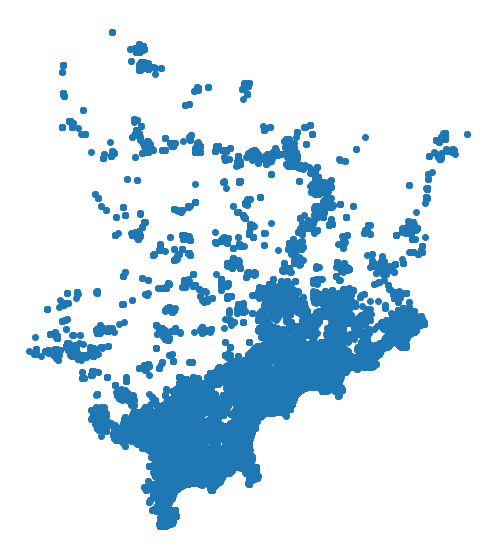

In [18]:
f, ax = plt.subplots(figsize=(10, 10))
ads.plot(ax=ax)
ax.set_axis_off()
plt.show()

    # CREATE GRAPH

In [19]:
## CREATE GRAPH WITH MOMEPY ON STREET
graph = momepy.gdf_to_nx(streets, approach='primal')

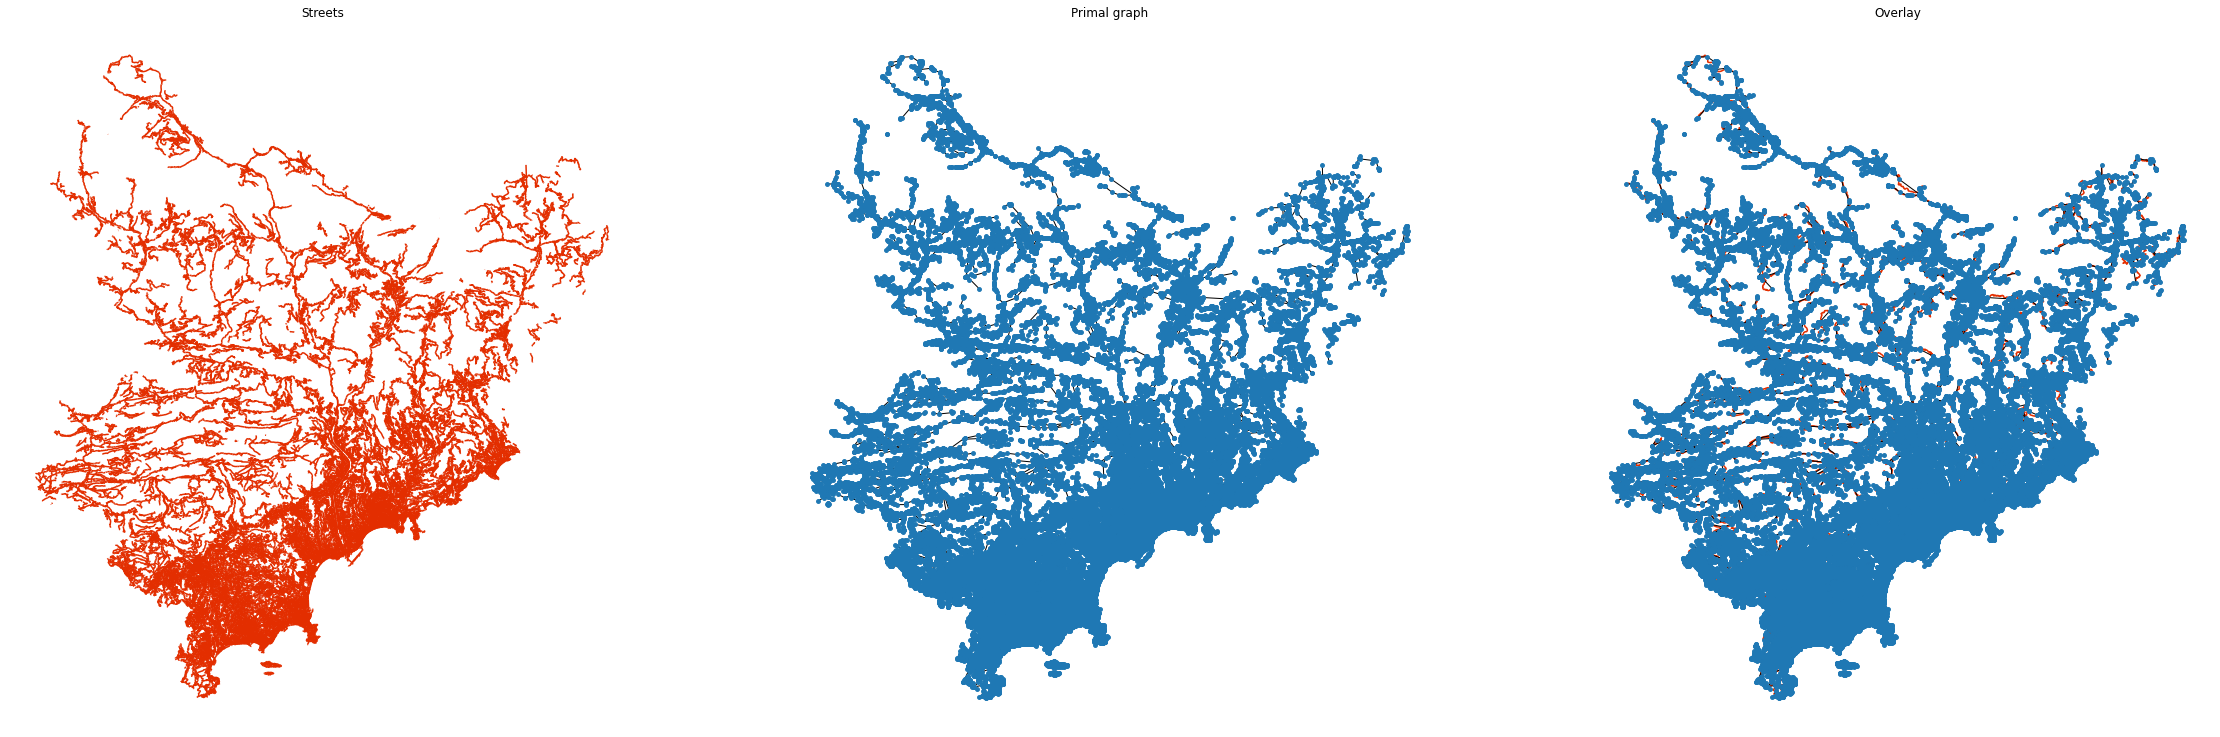

In [20]:
f, ax = plt.subplots(1, 3, figsize=(40, 13), sharex=True, sharey=True)
streets.plot(color='#e32e00', ax=ax[0])
for i, facet in enumerate(ax):
    facet.set_title(("Streets", "Primal graph", "Overlay")[i])
    facet.axis("off")
networkx.draw(graph, {n:[n[0], n[1]] for n in list(graph.nodes)}, ax=ax[1], node_size=15)
streets.plot(color='#e32e00', ax=ax[2], zorder=-1)
networkx.draw(graph, {n:[n[0], n[1]] for n in list(graph.nodes)}, ax=ax[2], node_size=15)

In [21]:
## CREATE NODES AND EDGES FROM GRAPH TO TRANSFORM NETWORKX OBJECT TO GDF OBJECT
nodes, edges, sw = momepy.nx_to_gdf(graph, points=True, lines=True, spatial_weights=True)

c:\users\ablanchi\appdata\local\programs\python\python36\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 647 disconnected components.
  warnings.warn(message)


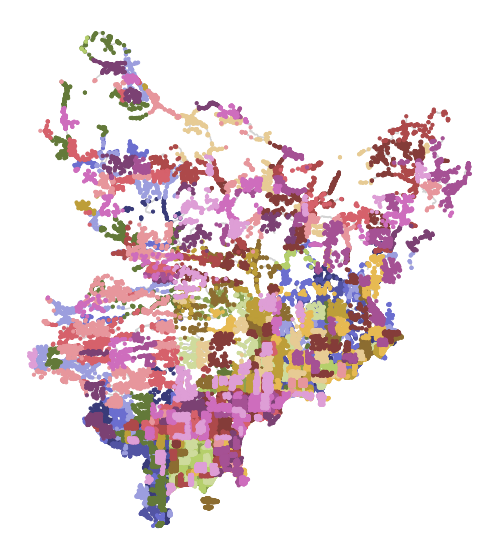

In [22]:
f, ax = plt.subplots(figsize=(10,10))
nodes.plot(ax=ax, cmap='tab20b', markersize=10, zorder=2)
edges.plot(ax=ax, color='lightgrey', zorder=1)
ax.set_axis_off()
plt.show()

In [23]:
## CREATE IDENTIFIER TO MERGE PIECES OF INFORMATION 
ads['new_col'] = range(1, len(ads) + 1)
ads

,idAnnonce,ET,EG,TOPONYME,ATTRIBUT,MD,relation_lem,eg_lem,cat_rs,clean_topo_v1,...,rs_eg,text_lieux,LAT,LONG,DESCRIPTION,VILLE,long,lat,geometry,new_col
0,61c20fa6f8e6291fd99d6537,m,non-qualifié,altitude,[],None,m,non-qualifié,OUT,altitude,...,PROX_non-qualifié,PROX_non-qualifié,43.866667,6.95000,"A une heure de NICE, 600 m d'altitude, proche ...",sigale,6.95000,43.866667,POINT (1017423.168 6315458.606),1
1,61c230c7f8e6291fd9c1a02e,bordure,village,aiglun,[],None,bordure,village,OUT,aiglun,...,PROX_village-cité,PROX_village-cité,43.857630,6.91482,Maison Aiglun\nAiglun-Sigale maison de village...,aiglun,6.91482,43.857630,POINT (1014648.184 6314314.879),2
2,61c230c7f8e6291fd9c1a02e,vue,nature,none,[],None,vue,nature,VW,none,...,verdoyant-bucolique-arboré,verdoyant-bucolique-arboré,43.857630,6.91482,Maison Aiglun\nAiglun-Sigale maison de village...,aiglun,6.91482,43.857630,POINT (1014648.184 6314314.879),3
3,61c2f05870007ef448aa2d38,vue,cascade,vegay,[],None,vue,cascade,VW,vegay,...,VW_cascade,VW_cascade,43.857630,6.91482,AIGLUN\nAu Grand Air des Pré-Alpes. Grande mai...,aiglun,6.91482,43.857630,POINT (1014648.184 6314314.879),4
4,61c2f05870007ef448aa2d38,none,non-qualifié,grand air,[],None,none,non-qualifié,IN,grand air,...,SIT_non-qualifié,SIT_non-qualifié,43.857630,6.91482,AIGLUN\nAu Grand Air des Pré-Alpes. Grande mai...,aiglun,6.91482,43.857630,POINT (1014648.184 6314314.879),5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255935,641e5d9b1821d80b0dc38de7,minutes,non-qualifié,limone,[],None,minute,non-qualifié,OUT,limone,...,PROX_non-qualifié,PROX_non-qualifié,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende,7.56191,44.055700,POINT (1065332.575 6339078.136),255936
255936,641e5d9b1821d80b0dc38de7,none,non-qualifié,monaco,[],None,none,non-qualifié,IN,monaco,...,SIT_non-qualifié,SIT_non-qualifié,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende,7.56191,44.055700,POINT (1065332.575 6339078.136),255937
255937,641e5d9b1821d80b0dc38de7,none,école,none,[],None,none,école,IN,none,...,PROX_école-collège-lycée,PROX_école-collège-lycée,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende,7.56191,44.055700,POINT (1065332.575 6339078.136),255938
255938,641e5d9b1821d80b0dc38de7,none,crèche,none,[],None,none,crèche,IN,none,...,PROX_école-collège-lycée,PROX_école-collège-lycée,44.055700,7.56191,"Idéal investisseur, amoureux de nature. Vendu ...",tende,7.56191,44.055700,POINT (1065332.575 6339078.136),255939


In [24]:
## BUILD GRAPH 
new_nodes, new_edges = connect_poi(ads, nodes, edges, key_col= "new_col")

Building rtree...
Updating external nodes...
Projecting POIs to the network...
Updating internal nodes...
Updating internal edges...
Updating external links...
Remove faulty projections: 2588/255940 (1.01%)
NOTE: duplication in node coordinates keys
Nodes count: 619984
Node coordinates key count: 233011
Missing 'from' nodes: 0
Missing 'to' nodes: 0


In [25]:
new_nodes = new_nodes ##Nodes + Nodes created
new_edges = new_edges ##Edges + Edges created
poi_links = new_edges[new_edges['highway'] == 'projected_footway'] ## Only Edges created

In [26]:
new_edges["from"].value_counts()

81214         77
122826        64
212539        60
182421        60
97774         59
              ..
9990201558     1
9990201564     1
9990201570     1
9990201575     1
9990045700     1
Name: from, Length: 125583, dtype: int64

In [27]:
new_edges["to"].value_counts()

9990206347    79
9990081213    78
9990197319    68
9990122825    65
9990212538    61
              ..
9990089546     1
9990217570     1
9990083828     1
9990053165     1
9990236271     1
Name: to, Length: 63165, dtype: int64

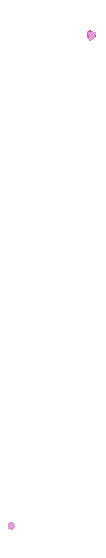

In [28]:
f, ax = plt.subplots(figsize=(10,10))
new_nodes.plot(ax=ax, cmap='tab20b', markersize=30, zorder=2)
new_edges.plot(ax=ax, color='grey', zorder=1)
poi_links.plot(ax=ax, color='red', zorder=1)
ads.plot(ax=ax, cmap='tab20b', markersize=3, zorder=2)
ax.set_axis_off()
plt.show()

In [29]:
## CREATE NEW COLUMNS TO CREATE UNIQUE KEY 
poi_links['new_col'] = poi_links["from"] ## idenfier of ads new_col## si elle n'existe pas ## CREATION MEME CHAMPS
new_nodes['to'] = new_nodes['osmid'] ## "to" is osmid and correspond to the "to" of new-edges-to ## CREATION MEME CHAMPS
#new_nodes['idx_nodes_all'] =  range(1, len(new_nodes) + 1) ## create id 
#new_edges['idx_edges_all'] =  range(1, len(new_edges) + 1) ## create id

In [30]:
## GET ONLY NEW NODES 
## #pl = poi_links    #pl.drop_duplicates()
ne = new_edges.merge(ads, on = ['new_col']) ## Links with information of ads.
ne 


#projected_pap = new_nodes[new_nodes['highway'] == "projected_pap"] ## Only nodes created
nn_only = new_nodes.merge(ne, on = ['to']) ## nodes with informations from poi_links qui ont été merged 
#nn_only = projected_pap.merge(ne, on = ['to']) ## nodes with informations from poi_links qui ont été merged 
nn_only #nn_only.to_excel("nn_only.xlsx")

,nodeID,geometry,osmid_x,highway_x,x,y,to,uid,troncon_de,troncon__1,...,text,rs_eg,text_lieux,LAT,LONG,DESCRIPTION,VILLE,long,lat,geometry_y
0,NaN,POINT (6.94991 43.86663),9.990000e+09,projected_pap,6.949914,43.866625,9.99e+09,NaN,NaN,NaN,...,non-qualifié,PROX_non-qualifié,PROX_non-qualifié,43.866667,6.950000,"A une heure de NICE, 600 m d'altitude, proche ...",sigale,6.950000,43.866667,POINT (1017423.168 6315458.606)
1,NaN,POINT (6.94991 43.86663),9.990000e+09,projected_pap,6.949914,43.866625,9.99e+09,NaN,NaN,NaN,...,village-cité,SIT_village-cité,SIT_village-cité,43.866667,6.950000,"Au centre du village de Sigale, un véritable C...",sigale,6.950000,43.866667,POINT (1017423.168 6315458.606)
2,NaN,POINT (6.94991 43.86663),9.990000e+09,projected_pap,6.949914,43.866625,9.99e+09,NaN,NaN,NaN,...,technopole-emploi-industriel,PROX_technopole-emploi-industriel,PROX_technopole-emploi-industriel,43.866667,6.950000,"Au centre du village de Sigale, un véritable C...",sigale,6.950000,43.866667,POINT (1017423.168 6315458.606)
3,NaN,POINT (6.94991 43.86663),9.990000e+09,projected_pap,6.949914,43.866625,9.99e+09,NaN,NaN,NaN,...,montagne-relief,VW_montagne-relief,VW_montagne-relief,43.866667,6.950000,"Au centre du village de Sigale, un véritable C...",sigale,6.950000,43.866667,POINT (1017423.168 6315458.606)
4,NaN,POINT (6.94991 43.86663),9.990000e+09,projected_pap,6.949914,43.866625,9.99e+09,NaN,NaN,NaN,...,non-qualifié,PROX_non-qualifié,PROX_non-qualifié,43.866667,6.950000,"Au centre du village de Sigale, un véritable C...",sigale,6.950000,43.866667,POINT (1017423.168 6315458.606)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253347,NaN,POINT (7.58605 44.05121),9.990256e+09,projected_pap,7.586050,44.051209,9.99026e+09,NaN,NaN,NaN,...,non-qualifié,PROX_non-qualifié,PROX_non-qualifié,44.050373,7.585782,SAINT DALMAS DE TENDE Appartement de 64 m² de ...,tende,7.585782,44.050373,POINT (1067276.514 6338598.034)
253348,NaN,POINT (7.58605 44.05121),9.990256e+09,projected_pap,7.586050,44.051209,9.99026e+09,NaN,NaN,NaN,...,non-qualifié,PROX_non-qualifié,PROX_non-qualifié,44.050373,7.585782,SAINT DALMAS DE TENDE Appartement de 64 m² de ...,tende,7.585782,44.050373,POINT (1067276.514 6338598.034)
253349,NaN,POINT (7.58605 44.05121),9.990256e+09,projected_pap,7.586050,44.051209,9.99026e+09,NaN,NaN,NaN,...,frontière,SIT_frontière,SIT_frontière,44.050373,7.585782,SAINT DALMAS DE TENDE Appartement de 64 m² de ...,tende,7.585782,44.050373,POINT (1067276.514 6338598.034)
253350,NaN,POINT (7.58605 44.05121),9.990256e+09,projected_pap,7.586050,44.051209,9.99026e+09,NaN,NaN,NaN,...,non-qualifié,SIT_non-qualifié,SIT_non-qualifié,44.050373,7.585782,SAINT DALMAS DE TENDE Appartement de 64 m² de ...,tende,7.585782,44.050373,POINT (1067276.514 6338598.034)


In [31]:
print('This dataframe is our points data geolocated on the network with ads information: nn_only')
print('This dataframe is our all edges created with ads inforamtion (used for create index key):  ne')

This dataframe is our points data geolocated on the network with ads information: nn_only
This dataframe is our all edges created with ads inforamtion (used for create index key):  ne


In [32]:
## NOW WE NEED TO TRANSFORM THE PARAMATERS OF EDGES (ORIGINE / DESTINATION)
print('You need to transform edges parameters because you do not have uniforms columns with origin and destination.')

#CHOOSE ONLY DATAFRAME OF EDGES WITHOUT THE EDGES BETWEEN NEWS NODES AND ADS. 
new_edges_bez_linkpoi = new_edges[new_edges['highway'] != 'projected_footway'] ## Only Edges created
new_edges_bez_linkpoi

You need to transform edges parameters because you do not have uniforms columns with origin and destination.


,uid,troncon_de,troncon__1,troncon__2,troncon__3,NOM_count,NOM_unique,NOM_empty,NOM_filled,NOM_min,...,mm_len,node_start,node_end,length,from,to,osmid,new_col,oneway,highway
0,7.423175e+07,TRONROUT0000000074231753,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,85.359806,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7.423175e+07,TRONROUT0000000074231754,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,28.946568,0.0,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.423176e+07,TRONROUT0000000074231755,Chemin,None,7.423176e+07,1.0,1.0,0.0,1.0,Auvare,...,260.192659,1.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.423232e+07,TRONROUT0000000074232317,Chemin,None,7.423232e+07,1.0,1.0,0.0,1.0,Auvare,...,1644.699393,1.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.423133e+07,TRONROUT0000000074231334,Chemin,None,7.423133e+07,2.0,2.0,0.0,2.0,Beuil,...,1834.928766,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207579,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,175.961565,107938.0,108033.0,125.517929,<NA>,9990236785,<NA>_9990236785,NaN,NaN,NaN
207580,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,175.961565,107938.0,108033.0,118.021610,9990236785,<NA>,9990236785_<NA>,NaN,NaN,NaN
207581,2.005926e+09,TRONROUT0000002005925926,Chemin,None,2.005926e+09,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,238.303056,107952.0,107953.0,151.279066,9990236440,9990236874,9990236440_9990236874,NaN,NaN,NaN
207582,2.005926e+09,TRONROUT0000002005925926,Chemin,None,2.005926e+09,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,238.303056,107952.0,107953.0,178.581619,9990236874,<NA>,9990236874_<NA>,NaN,NaN,NaN


In [33]:
#E.G. 1
new_edges_bez_linkpoi[new_edges_bez_linkpoi['from'] == 9990000001][['from', 'to', 'node_start', 'node_end','length']]

,from,to,node_start,node_end,length


In [34]:
#E.G. 2
new_edges_bez_linkpoi[new_edges_bez_linkpoi['to'] == 9990000001][['from', 'to', 'node_start','node_end','length']]

,from,to,node_start,node_end,length


In [35]:
#E.G. 3
new_edges_bez_linkpoi[new_edges_bez_linkpoi['node_end'] == 33][['from', 'to', 'node_start','node_end','length']]

,from,to,node_start,node_end,length
10,NaN,NaN,5.0,33.0,NaN
25,NaN,NaN,14.0,33.0,NaN


In [36]:
#E.G. 4
new_edges_bez_linkpoi[new_edges_bez_linkpoi['node_end'] == 40][['from', 'to', 'node_start', 'node_end','length']]

,from,to,node_start,node_end,length
56,NaN,NaN,39.0,40.0,NaN


In [37]:
new_edges_bez_linkpoi["from"]

0                NaN
1                NaN
2                NaN
3                NaN
4                NaN
             ...    
207579          <NA>
207580    9990236785
207581    9990236440
207582    9990236874
207583          <NA>
Name: from, Length: 180776, dtype: object

In [38]:
## MODIFICATION OF EDGES PARAMETERS (ORGINE / DESTINATION)
new_edges_bez_linkpoi = new_edges_bez_linkpoi.fillna("None")
new_edges_bez_linkpoi['idx_edges'] =  range(1, len(new_edges_bez_linkpoi) + 1) ## create id
new_edges_bez_linkpoi['to_id'] = new_edges_bez_linkpoi.apply(lambda x : str(x['to']) if (x['to'] != "None") else str(x['node_end']), axis=1)
new_edges_bez_linkpoi['from_id'] = new_edges_bez_linkpoi.apply(lambda x : str(x['from']) if (x['from'] != "None") else str(x['node_start']), axis=1)
new_edges_bez_linkpoi.set_index("idx_edges", inplace = True)
new_edges_bez_linkpoi ## ALL OUR EDGES

,uid,troncon_de,troncon__1,troncon__2,troncon__3,NOM_count,NOM_unique,NOM_empty,NOM_filled,NOM_min,...,node_end,length,from,to,osmid,new_col,oneway,highway,to_id,from_id
idx_edges,,,,,,,,,,,,,,,,,,,,,
1,7.423175e+07,TRONROUT0000000074231753,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,1.0,None,None,None,None,None,None,None,1.0,0.0
2,7.423175e+07,TRONROUT0000000074231754,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,61.0,None,None,None,None,None,None,None,61.0,0.0
3,7.423176e+07,TRONROUT0000000074231755,Chemin,None,7.423176e+07,1.0,1.0,0.0,1.0,Auvare,...,22.0,None,None,None,None,None,None,None,22.0,1.0
4,7.423232e+07,TRONROUT0000000074232317,Chemin,None,7.423232e+07,1.0,1.0,0.0,1.0,Auvare,...,50.0,None,None,None,None,None,None,None,50.0,1.0
5,7.423133e+07,TRONROUT0000000074231334,Chemin,None,7.423133e+07,2.0,2.0,0.0,2.0,Beuil,...,3.0,None,None,None,None,None,None,None,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180772,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,108033.0,125.518,None,9990236785,<NA>_9990236785,None,None,None,9990236785,107938.0
180773,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,108033.0,118.022,9990236785,None,9990236785_<NA>,None,None,None,108033.0,9990236785
180774,2.005926e+09,TRONROUT0000002005925926,Chemin,None,2.005926e+09,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,107953.0,151.279,9990236440,9990236874,9990236440_9990236874,None,None,None,9990236874,9990236440


In [39]:
#SHOW RESULT 
new_edges_bez_linkpoi[new_edges_bez_linkpoi['node_end'] == 40][['from', 'to', 'node_start', 'node_end','length', 'from_id', 'to_id']]

,from,to,node_start,node_end,length,from_id,to_id
idx_edges,,,,,,,
56,None,None,39.0,40.0,None,39.0,40.0


In [40]:
print('This dataframe is ALL EDGES of our network modified, we gonna work only with this df : new_edges_bez_linkpoi ')

This dataframe is ALL EDGES of our network modified, we gonna work only with this df : new_edges_bez_linkpoi 


In [41]:
## CREATE DATAFRAME OF NODES 
new_nodes
new_nodes = new_nodes.fillna("None")
nodes_without_ADS = new_nodes[new_nodes['highway'] != "poi"] ## Only Edges created
nodes_without_ADS['indentifier'] = nodes_without_ADS.apply(lambda x : str(x['osmid']) if (x['osmid'] != "None") else str(x['nodeID']), axis=1)
nodes_without_ADS['IDX_create'] = nodes_without_ADS.apply(lambda x : str(x['osmid']) if (x['osmid'] != "None") else str(x['nodeID']), axis=1)
nodes_without_ADS.set_index("indentifier", inplace = True)
nodes_without_ADS ## ALL OUR NODES


,nodeID,geometry,osmid,highway,x,y,to,IDX_create
indentifier,,,,,,,,
0.0,0,POINT (6.92583 44.04299),None,None,6.925829,44.042992,None,0.0
1.0,1,POINT (6.92607 44.04234),None,None,6.926074,44.042343,None,1.0
2.0,2,POINT (6.95929 44.04746),None,None,6.959291,44.047457,None,2.0
3.0,3,POINT (6.94112 44.04404),None,None,6.941117,44.044045,None,3.0
4.0,4,POINT (6.97614 44.04378),None,None,6.976138,44.043784,None,4.0
...,...,...,...,...,...,...,...,...
9990255935.0,None,POINT (7.56291 44.05737),9.99026e+09,projected_pap,7.562915,44.057373,9.99026e+09,9990255935.0
9990255936.0,None,POINT (7.56291 44.05737),9.99026e+09,projected_pap,7.562915,44.057373,9.99026e+09,9990255936.0
9990255937.0,None,POINT (7.56291 44.05737),9.99026e+09,projected_pap,7.562915,44.057373,9.99026e+09,9990255937.0


In [42]:
print('This dataframe is ALL NODES of our network modified, we gonna work only with this df : nodes_without_ADS ')

This dataframe is ALL NODES of our network modified, we gonna work only with this df : nodes_without_ADS 


In [43]:
print('OUR NEW NETWORK IS COMPOSED TO TWO DATAFRAME : 1/ EDGES == "new_edges_bez_linkpoi" 2/ NODES == "nodes_without_ADS"')

OUR NEW NETWORK IS COMPOSED TO TWO DATAFRAME : 1/ EDGES == "new_edges_bez_linkpoi" 2/ NODES == "nodes_without_ADS"


In [44]:
## ADD ADS INFORMATION 
nodes_without_ADS_with_information = nodes_without_ADS.merge(ne,how='left', on = ['to']) ## nodes with informations from poi_links qui ont été merged 
nodes_without_ADS_with_information ## ALL NODES WITH INFORMATION OF ADS

,nodeID,geometry,osmid_x,highway_x,x,y,to,IDX_create,uid,troncon_de,...,text,rs_eg,text_lieux,LAT,LONG,DESCRIPTION,VILLE,long,lat,geometry_y
0,0,POINT (6.92583 44.04299),None,None,6.925829,44.042992,None,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,1,POINT (6.92607 44.04234),None,None,6.926074,44.042343,None,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,2,POINT (6.95929 44.04746),None,None,6.959291,44.047457,None,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,3,POINT (6.94112 44.04404),None,None,6.941117,44.044045,None,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,4,POINT (6.97614 44.04378),None,None,6.976138,44.043784,None,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554805,None,POINT (7.56291 44.05737),9.99026e+09,projected_pap,7.562915,44.057373,9.99026e+09,9990255935.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
554806,None,POINT (7.56291 44.05737),9.99026e+09,projected_pap,7.562915,44.057373,9.99026e+09,9990255936.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
554807,None,POINT (7.56291 44.05737),9.99026e+09,projected_pap,7.562915,44.057373,9.99026e+09,9990255937.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
554808,None,POINT (7.56291 44.05737),9.99026e+09,projected_pap,7.562915,44.057373,9.99026e+09,9990255938.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [45]:
new_edges_bez_linkpoi

,uid,troncon_de,troncon__1,troncon__2,troncon__3,NOM_count,NOM_unique,NOM_empty,NOM_filled,NOM_min,...,node_end,length,from,to,osmid,new_col,oneway,highway,to_id,from_id
idx_edges,,,,,,,,,,,,,,,,,,,,,
1,7.423175e+07,TRONROUT0000000074231753,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,1.0,None,None,None,None,None,None,None,1.0,0.0
2,7.423175e+07,TRONROUT0000000074231754,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,61.0,None,None,None,None,None,None,None,61.0,0.0
3,7.423176e+07,TRONROUT0000000074231755,Chemin,None,7.423176e+07,1.0,1.0,0.0,1.0,Auvare,...,22.0,None,None,None,None,None,None,None,22.0,1.0
4,7.423232e+07,TRONROUT0000000074232317,Chemin,None,7.423232e+07,1.0,1.0,0.0,1.0,Auvare,...,50.0,None,None,None,None,None,None,None,50.0,1.0
5,7.423133e+07,TRONROUT0000000074231334,Chemin,None,7.423133e+07,2.0,2.0,0.0,2.0,Beuil,...,3.0,None,None,None,None,None,None,None,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180772,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,108033.0,125.518,None,9990236785,<NA>_9990236785,None,None,None,9990236785,107938.0
180773,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,108033.0,118.022,9990236785,None,9990236785_<NA>,None,None,None,108033.0,9990236785
180774,2.005926e+09,TRONROUT0000002005925926,Chemin,None,2.005926e+09,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,107953.0,151.279,9990236440,9990236874,9990236440_9990236874,None,None,None,9990236874,9990236440


In [46]:
## PAS SUR 
new_edges_bez_linkpoi['new_col_str'] = new_edges_bez_linkpoi.new_col.astype(str)
ne['new_col_str'] = ne.new_col.astype(str)
ads['new_col_str'] = ads.new_col.astype(str)
new_edges_bez_linkpoi_with_ads_information = new_edges_bez_linkpoi.merge(ads, how = 'left', on = ['new_col_str'])
list(new_edges_bez_linkpoi_with_ads_information.columns)
new_edges_bez_linkpoi

,uid,troncon_de,troncon__1,troncon__2,troncon__3,NOM_count,NOM_unique,NOM_empty,NOM_filled,NOM_min,...,length,from,to,osmid,new_col,oneway,highway,to_id,from_id,new_col_str
idx_edges,,,,,,,,,,,,,,,,,,,,,
1,7.423175e+07,TRONROUT0000000074231753,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,None,None,None,None,None,None,None,1.0,0.0,None
2,7.423175e+07,TRONROUT0000000074231754,Chemin,None,7.423175e+07,1.0,1.0,0.0,1.0,Auvare,...,None,None,None,None,None,None,None,61.0,0.0,None
3,7.423176e+07,TRONROUT0000000074231755,Chemin,None,7.423176e+07,1.0,1.0,0.0,1.0,Auvare,...,None,None,None,None,None,None,None,22.0,1.0,None
4,7.423232e+07,TRONROUT0000000074232317,Chemin,None,7.423232e+07,1.0,1.0,0.0,1.0,Auvare,...,None,None,None,None,None,None,None,50.0,1.0,None
5,7.423133e+07,TRONROUT0000000074231334,Chemin,None,7.423133e+07,2.0,2.0,0.0,2.0,Beuil,...,None,None,None,None,None,None,None,3.0,2.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180772,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,125.518,None,9990236785,<NA>_9990236785,None,None,None,9990236785,107938.0,None
180773,7.429489e+07,TRONROUT0000000074294891,Route à 1 chaussée,None,7.429489e+07,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,118.022,9990236785,None,9990236785_<NA>,None,None,None,108033.0,9990236785,None
180774,2.005926e+09,TRONROUT0000002005925926,Chemin,None,2.005926e+09,1.0,1.0,0.0,1.0,Tourrettes-sur-Loup,...,151.279,9990236440,9990236874,9990236440_9990236874,None,None,None,9990236874,9990236440,None


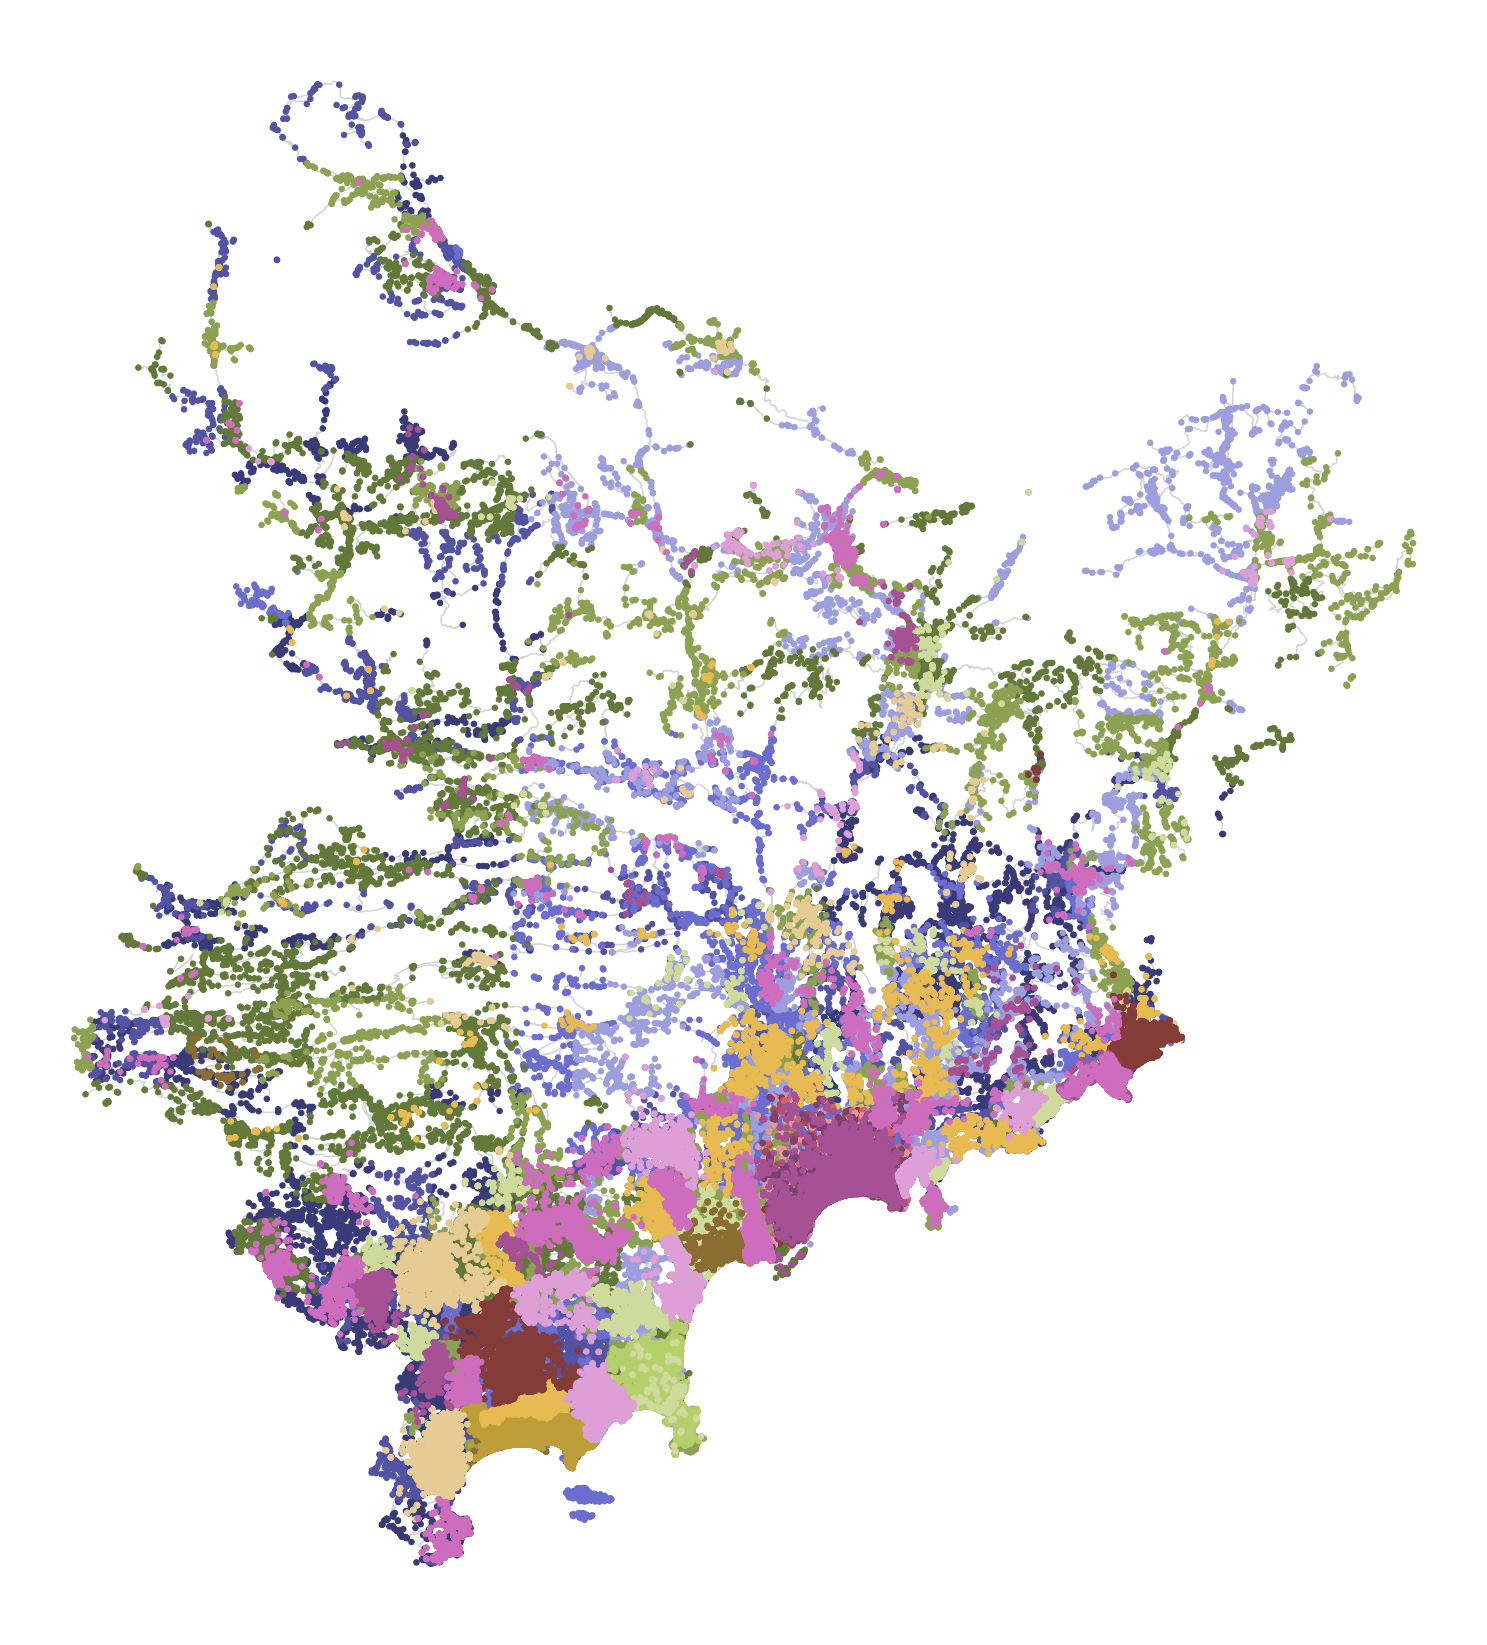

In [47]:
### PLOT RESULT OF NETWORK MODIFIED 
f, ax = plt.subplots(figsize=(30,30))
nodes_without_ADS.plot(ax=ax, cmap='tab20b', markersize=30, zorder=2)
#new_edges.plot(ax=ax, color='green', zorder=1)
new_edges_bez_linkpoi.plot(ax=ax, color='lightgrey', zorder=1)
#poi_links.plot(ax=ax, color='red', zorder=1)
#ads.plot(ax=ax, cmap='tab20b', markersize=3, zorder=2)
ax.set_axis_off()
plt.show()

In [48]:
print('Mon nouveau réseau routier est composé : ')
print('------ EDGES = new_edges_bez_linkpoi', '____longueur ___', len(new_edges_bez_linkpoi))
print('------ NODES = nodes_without_ADS_with_information', '____longueur ___',len(nodes_without_ADS_with_information))

Mon nouveau réseau routier est composé : 
------ EDGES = new_edges_bez_linkpoi ____longueur ___ 180776
------ NODES = nodes_without_ADS_with_information ____longueur ___ 554810


# save

In [43]:
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/Python_sorties/1_ADS_RELOCALIZED.csv"
nn_only.to_csv(path)

In [44]:
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/Python_sorties/1_ADS_RELOCALIZED.pickle"
print("- Pour la ville : __", VILLE, "__ Le chemin est le suivant : ", path)
file = open(path, "wb")
pickle.dump(nn_only, file)
file.close()

- Pour la ville : __ CANNES __ Le chemin est le suivant :  C:/GIT/2022/TOPONOMASCAPE/VILLE/CANNES/Python_sorties/1_ADS_RELOCALIZED.pickle


<AxesSubplot:>

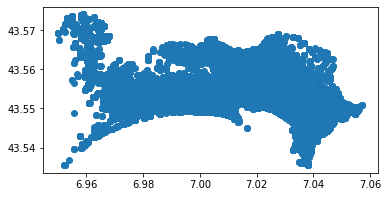

In [45]:
nn_only.plot()

In [49]:
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/1_ADS_RELOCALIZED.csv"
nn_only.to_csv(path)

In [50]:
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/1_ADS_RELOCALIZED.pickle"
print("- Pour la ville : __", VILLE, "__ Le chemin est le suivant : ", path)
file = open(path, "wb")
pickle.dump(nn_only, file)
file.close()

- Pour la ville : __ ALPES-MARITIMES __ Le chemin est le suivant :  C:/GIT/2022/TOPONOMASCAPE/VILLE/ALPES-MARITIMES/1_ADS_RELOCALIZED.pickle
